In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data=pd.read_csv("2  powerplant_data.csv")

In [4]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
x=data.drop("PE",axis=1)
y=data["PE"]

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [9]:
#converting into tensors
import torch 
import torch.nn as nn

x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [10]:
from torch.utils.data import TensorDataset,DataLoader 

train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

In [11]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [12]:
x_train.shape

(7654, 4)

 ## deep learning

In [13]:
# define an ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [14]:
import torch.optim as optim
model=ANN()

criteria=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [15]:
# train the ANN
train_losses=[]
val_losses=[]
best_val_loss=float("inf")

epochs=50
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    
    for xb,yb in train_loader:
        optimizer.zero_grad() 
        
        outputs=model(xb)
        loss=criteria(outputs,yb)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criteria(outputs,yb)

            running_val_loss+=loss.item()
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss ={epoch_train_loss} & val loss =  {epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch 1/50 ==> training loss =206135.07005208332 & val loss =  204072.45130208333
epoch 2/50 ==> training loss =196809.007421875 & val loss =  183800.6484375
epoch 3/50 ==> training loss =159271.006640625 & val loss =  129995.82447916667
epoch 4/50 ==> training loss =97121.15428059896 & val loss =  66616.07825520834
epoch 5/50 ==> training loss =45188.227864583336 & val loss =  30066.72607421875
epoch 6/50 ==> training loss =23422.50048014323 & val loss =  19188.259505208334
epoch 7/50 ==> training loss =17120.152864583335 & val loss =  15178.715852864583
epoch 8/50 ==> training loss =13748.424391682942 & val loss =  11973.008479817709
epoch 9/50 ==> training loss =10668.880314127604 & val loss =  8994.383805338543
epoch 10/50 ==> training loss =7718.012068684896 & val loss =  6265.669868977865
epoch 11/50 ==> training loss =5187.877603149414 & val loss =  4013.3098775227863
epoch 12/50 ==> training loss =3206.6287689208984 & val loss =  2423.811048380534
epoch 13/50 ==> training loss 

Text(0.5, 1.0, 'Training vs Validation Loss')

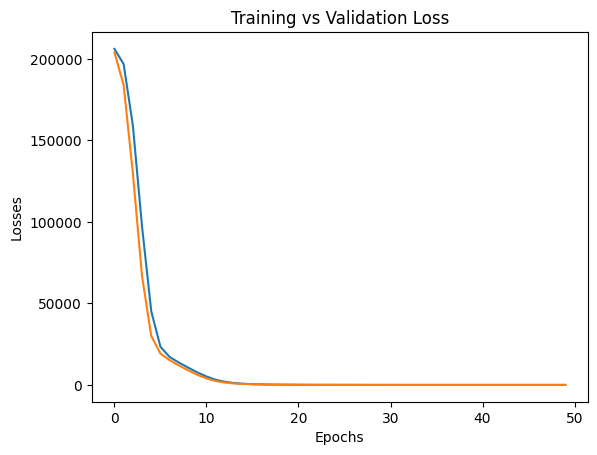

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Training vs Validation Loss")


In [17]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [19]:
# evaluation
model.eval()
with torch.no_grad():
    train_pred=model(x_train_tensor)
    test_pred=model(x_test_tensor)

    train_mse_loss=criteria(train_pred,x_train_tensor)
    test_mse_loss=criteria(test_pred,x_test_tensor)

print("training mse:",train_mse_loss.item())
print("testing mse:",test_mse_loss.item())

training mse: 206207.15625
testing mse: 206298.109375


In [22]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test, test_pred))

r^2 score = 0.9322730348384394


In [24]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.766357,433.27
1,436.118622,438.16
2,461.305756,458.42
3,476.181885,480.82
4,435.170532,441.41
...,...,...
1909,450.698456,456.70
1910,430.942139,438.04
1911,467.349060,467.80
1912,430.357300,437.14
